In [3]:
import os
import pandas as pd
import numpy as np

fichier = "/home/diglo/Downloads/churn_trainingdataset.csv"

# Vérifier que le fichier existe
print("Fichier trouvé :", os.path.exists(fichier))

# Charger le dataset
df = pd.read_csv(fichier)

print("Nombre d'observations :", df.shape[0])
print("Nombre de variables :", df.shape[1])

display(df.head())

Fichier trouvé : True
Nombre d'observations : 2667
Nombre de variables : 16


,Phone,Account.Length,Day.Mins,Day.Calls,Day.Charge,Eve.Mins,Eve.Calls,Eve.Charge,Night.Mins,Night.Calls,Night.Charge,Intl.Mins,Intl.Calls,Intl.Charge,CustServ.Calls,Churn.
0,382-4657,128,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,371-7191,107,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,358-1921,137,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,375-9999,84,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,330-6626,75,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [4]:
# Nombre de valeurs manquantes par variable
missing = df.isnull().sum()

print("Valeurs manquantes :")
print(missing)

print("\nTotal des valeurs manquantes :", missing.sum())

Valeurs manquantes :
Phone             0
Account.Length    0
Day.Mins          0
Day.Calls         0
Day.Charge        0
Eve.Mins          0
Eve.Calls         0
Eve.Charge        0
Night.Mins        0
Night.Calls       0
Night.Charge      0
Intl.Mins         0
Intl.Calls        0
Intl.Charge       0
CustServ.Calls    0
Churn.            0
dtype: int64

Total des valeurs manquantes : 0


In [5]:
# Doublons
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


In [6]:
# Identifiant
identifiant = df["Phone"].copy()

# Variable cible
y = df["Churn."].copy()

# Variables explicatives
X = df.drop(columns=["Phone", "Churn."])

print("Variables utilisées pour les nuées dynamiques :")
print(X.columns.tolist())

print("\nDimensions de X :", X.shape)

Variables utilisées pour les nuées dynamiques :
['Account.Length', 'Day.Mins', 'Day.Calls', 'Day.Charge', 'Eve.Mins', 'Eve.Calls', 'Eve.Charge', 'Night.Mins', 'Night.Calls', 'Night.Charge', 'Intl.Mins', 'Intl.Calls', 'Intl.Charge', 'CustServ.Calls']

Dimensions de X : (2667, 14)


In [7]:
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
Account.Length,2667.0,101.246344,39.515839,1.00,74.000,101.00,127.000,243.00
Day.Mins,2667.0,179.752943,54.607640,0.00,143.750,179.30,216.850,350.80
Day.Calls,2667.0,100.198350,19.859277,0.00,87.000,101.00,113.000,165.00
Day.Charge,2667.0,30.558538,9.283274,0.00,24.440,30.48,36.865,59.64
Eve.Mins,2667.0,201.467942,50.233057,0.00,167.250,202.30,235.100,363.70
Eve.Calls,2667.0,100.176978,20.059761,0.00,87.000,100.00,114.000,170.00
Eve.Charge,2667.0,17.124983,4.269803,0.00,14.215,17.20,19.980,30.91
Night.Mins,2667.0,200.563780,50.406868,23.20,166.800,200.80,234.900,395.00
Night.Calls,2667.0,100.157480,19.624550,33.00,87.000,100.00,114.000,175.00
Night.Charge,2667.0,9.025444,2.268342,1.04,7.510,9.04,10.570,17.77


In [8]:
# Conversion en matrice numpy
X_array = X.to_numpy(dtype=float)

# Moyenne de chaque variable
moyennes = np.mean(X_array, axis=0)

# Écart-type de chaque variable
ecarts_types = np.std(X_array, axis=0)

# Standardisation
X_standardise = (X_array - moyennes) / ecarts_types

print("Dimensions :", X_standardise.shape)

print("\nMoyennes après standardisation :")
print(np.mean(X_standardise, axis=0))

print("\nÉcarts-types après standardisation :")
print(np.std(X_standardise, axis=0))

Dimensions : (2667, 14)

Moyennes après standardisation :
[-2.13136179e-17  1.16558848e-16  1.06568089e-16  3.37687633e-16
 -1.47863224e-16 -1.23885404e-16  6.39408536e-17 -7.32655614e-16
 -3.42349987e-16  7.72618648e-16 -5.32840447e-18  1.69842892e-17
  3.33025279e-16 -3.59667302e-17]

Écarts-types après standardisation :
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [9]:
def distance_euclidienne(x, g):
    """
    Calcule la distance euclidienne entre
    deux vecteurs x et g.
    """
    
    distance = np.sqrt(
        np.sum((x - g) ** 2)
    )
    
    return distance

In [10]:
x1 = X_standardise[0]
x2 = X_standardise[1]

d = distance_euclidienne(x1, x2)

print("Distance entre le client 1 et le client 2 :", d)

Distance entre le client 1 et le client 2 : 3.4484724036096384


In [11]:
def initialiser_prototypes(X, K, random_state=42):
    
    rng = np.random.default_rng(random_state)
    
    indices = rng.choice(
        len(X),
        size=K,
        replace=False
    )
    
    prototypes = X[indices].copy()
    
    return prototypes

In [12]:
K = 3

prototypes = initialiser_prototypes(
    X_standardise,
    K,
    random_state=42
)

print("Dimensions des prototypes :", prototypes.shape)

print("\nPrototypes initiaux :")
print(prototypes)

Dimensions des prototypes : (3, 14)

Prototypes initiaux :
[[ 0.1962532   0.25362117 -2.1252669   0.25334848 -1.05065947  0.73908167
  -1.05059289  1.62580197  0.24680452  1.62464299  1.01789206 -1.41952946
   1.02116987  0.32564435]
 [-0.68963368 -1.72266337 -0.8661733  -1.72261815  0.92052388 -1.65421707
   0.91942259 -1.15410239 -0.77251822 -1.15323628 -0.05415859  0.19716108
  -0.05092301  0.32564435]
 [ 2.06927117 -1.30872425 -0.66471833 -1.30889341 -0.35576756  0.78894206
  -0.35487993 -0.47549618  0.45066907 -0.47419912  1.16083215 -1.01535682
   1.16676273 -1.18215682]]


In [13]:
def affecter_individus(X, prototypes):
    
    labels = []
    
    for x in X:
        
        distances = []
        
        for g in prototypes:
            
            d = distance_euclidienne(x, g)
            distances.append(d)
        
        classe = np.argmin(distances)
        
        labels.append(classe)
    
    return np.array(labels)

In [14]:
labels = affecter_individus(
    X_standardise,
    prototypes
)

print("Premières affectations :")
print(labels[:20])

Premières affectations :
[0 2 2 0 0 1 1 2 1 0 1 2 1 1 1 1 1 0 2 1]


In [15]:
def recalculer_prototypes(X, labels, K, anciens_prototypes):
    """
    Recalcule les prototypes de chaque classe.
    """
    
    nouveaux_prototypes = []
    
    for k in range(K):
        
        # Individus appartenant à la classe k
        individus = X[labels == k]
        
        if len(individus) > 0:
            # Centre de gravité de la classe
            prototype = np.mean(individus, axis=0)
        
        else:
            # Si la classe est vide, on conserve
            # l'ancien prototype
            prototype = anciens_prototypes[k]
        
        nouveaux_prototypes.append(prototype)
    
    return np.array(nouveaux_prototypes)

In [16]:
nouveaux_prototypes = recalculer_prototypes(
    X_standardise,
    labels,
    K,
    prototypes
)

print("Anciens prototypes :")
print(prototypes)

print("\nNouveaux prototypes :")
print(nouveaux_prototypes)

Anciens prototypes :
[[ 0.1962532   0.25362117 -2.1252669   0.25334848 -1.05065947  0.73908167
  -1.05059289  1.62580197  0.24680452  1.62464299  1.01789206 -1.41952946
   1.02116987  0.32564435]
 [-0.68963368 -1.72266337 -0.8661733  -1.72261815  0.92052388 -1.65421707
   0.91942259 -1.15410239 -0.77251822 -1.15323628 -0.05415859  0.19716108
  -0.05092301  0.32564435]
 [ 2.06927117 -1.30872425 -0.66471833 -1.30889341 -0.35576756  0.78894206
  -0.35487993 -0.47549618  0.45066907 -0.47419912  1.16083215 -1.01535682
   1.16676273 -1.18215682]]

Nouveaux prototypes :
[[-0.16018191  0.5320896  -0.19816378  0.53208849 -0.36679814  0.18373027
  -0.36681421  0.75801678  0.0566124   0.75803305  0.11774481 -0.11335055
   0.11777191  0.13458735]
 [-0.31872569 -0.26852795 -0.00271277 -0.26852675  0.46357909 -0.39078701
   0.46358992 -0.42089217 -0.17977042 -0.42088057 -0.36595684  0.15797324
  -0.36591289  0.15436845]
 [ 0.64359781 -0.24846968  0.23876226 -0.24847006 -0.22512861  0.33851179
  -0.2

In [17]:
def changement_prototypes(anciens, nouveaux):
    
    return np.linalg.norm(
        nouveaux - anciens
    )

In [18]:
variation = changement_prototypes(
    prototypes,
    nouveaux_prototypes
)

print("Variation des prototypes :", variation)

Variation des prototypes : 5.207223038575176


In [19]:
def calculer_inertie(X, labels, prototypes):
    
    inertie = 0.0
    
    for i in range(len(X)):
        
        x = X[i]
        
        # Prototype correspondant à la classe
        g = prototypes[labels[i]]
        
        # Distance au carré
        distance_carre = np.sum(
            (x - g) ** 2
        )
        
        inertie += distance_carre
    
    return inertie

In [20]:
inertie = calculer_inertie(
    X_standardise,
    labels,
    nouveaux_prototypes
)

print("Inertie intra-classe :", inertie)

Inertie intra-classe : 32762.4818600948


In [21]:
def nuees_dynamiques(
    X,
    K,
    max_iter=100,
    tol=1e-4,
    random_state=42
):
    """
    Algorithme des nuées dynamiques
    implémenté from scratch.
    """
    
    # ------------------------------------------------
    # INITIALISATION
    # ------------------------------------------------
    
    prototypes = initialiser_prototypes(
        X,
        K,
        random_state
    )
    
    historique_inertie = []
    
    # ------------------------------------------------
    # ITERATIONS
    # ------------------------------------------------
    
    for iteration in range(max_iter):
        
        # 1. Affectation
        labels = affecter_individus(
            X,
            prototypes
        )
        
        # 2. Recalcul des prototypes
        nouveaux_prototypes = recalculer_prototypes(
            X,
            labels,
            K,
            prototypes
        )
        
        # 3. Calcul de l'inertie
        inertie = calculer_inertie(
            X,
            labels,
            nouveaux_prototypes
        )
        
        historique_inertie.append(inertie)
        
        # 4. Mesure du déplacement
        variation = changement_prototypes(
            prototypes,
            nouveaux_prototypes
        )
        
        # Affichage de l'évolution
        print(
            f"Itération {iteration + 1:3d} | "
            f"Inertie = {inertie:.4f} | "
            f"Variation = {variation:.6f}"
        )
        
        # 5. Mise à jour
        prototypes = nouveaux_prototypes
        
        # 6. Critère d'arrêt
        if variation < tol:
            print("\nConvergence atteinte.")
            break
    
    return {
        "labels": labels,
        "prototypes": prototypes,
        "inertie": inertie,
        "historique_inertie": historique_inertie,
        "iterations": iteration + 1
    }

In [22]:
import pandas as pd
import numpy as np

fichier = "/home/diglo/Downloads/churn_trainingdataset.csv"

df = pd.read_csv(fichier)

print("Dimensions :", df.shape)

Dimensions : (2667, 16)


In [23]:
identifiant = df["Phone"].copy()

y = df["Churn."].copy()

X = df.drop(
    columns=["Phone", "Churn."]
)

In [24]:
X_array = X.to_numpy(dtype=float)

In [25]:
moyennes = np.mean(
    X_array,
    axis=0
)

ecarts_types = np.std(
    X_array,
    axis=0
)

X_standardise = (
    X_array - moyennes
) / ecarts_types

In [26]:
resultat = nuees_dynamiques(
    X_standardise,
    K=3,
    max_iter=100,
    tol=1e-4,
    random_state=42
)

Itération   1 | Inertie = 32762.4819 | Variation = 5.207223
Itération   2 | Inertie = 32142.4624 | Variation = 0.575455
Itération   3 | Inertie = 31812.2244 | Variation = 0.385828
Itération   4 | Inertie = 31682.2521 | Variation = 0.236060
Itération   5 | Inertie = 31630.2298 | Variation = 0.148758
Itération   6 | Inertie = 31608.7722 | Variation = 0.104132
Itération   7 | Inertie = 31598.9040 | Variation = 0.067213
Itération   8 | Inertie = 31596.6034 | Variation = 0.029773
Itération   9 | Inertie = 31594.1346 | Variation = 0.039436
Itération  10 | Inertie = 31590.4317 | Variation = 0.049085
Itération  11 | Inertie = 31587.2304 | Variation = 0.044551
Itération  12 | Inertie = 31585.1133 | Variation = 0.036169
Itération  13 | Inertie = 31583.5478 | Variation = 0.029390
Itération  14 | Inertie = 31580.9212 | Variation = 0.042802
Itération  15 | Inertie = 31578.4648 | Variation = 0.035760
Itération  16 | Inertie = 31575.5684 | Variation = 0.041594
Itération  17 | Inertie = 31572.8951 | V

In [27]:
labels = resultat["labels"]

prototypes = resultat["prototypes"]

inertie = resultat["inertie"]

historique = resultat["historique_inertie"]

iterations = resultat["iterations"]

In [28]:
print("\n==============================")
print("RESULTATS")
print("==============================")

print("Nombre de clusters :", 3)
print("Nombre d'itérations :", iterations)
print("Inertie finale :", inertie)

print("\nTaille des clusters :")

for k in range(3):
    
    nombre = np.sum(labels == k)
    
    print(
        f"Cluster {k+1} : {nombre} clients"
    )


RESULTATS
Nombre de clusters : 3
Nombre d'itérations : 52
Inertie finale : 31513.012046030497

Taille des clusters :
Cluster 1 : 892 clients
Cluster 2 : 838 clients
Cluster 3 : 937 clients


In [29]:
analyse_clusters = pd.DataFrame({
    "Cluster": labels,
    "Churn": y.values
})

print(analyse_clusters.head())

   Cluster   Churn
0        0  False.
1        0  False.
2        0  False.
3        0  False.
4        0  False.


In [30]:
df_profil = X.copy()

df_profil["Cluster"] = labels

profil_clusters = (
    df_profil
    .groupby("Cluster")
    .mean()
)

display(profil_clusters)

,Account.Length,Day.Mins,Day.Calls,Day.Charge,Eve.Mins,Eve.Calls,Eve.Charge,Night.Mins,Night.Calls,Night.Charge,Intl.Mins,Intl.Calls,Intl.Charge,CustServ.Calls
Cluster,,,,,,,,,,,,,,
0,102.056054,205.921076,101.317265,35.007085,177.780493,103.343049,15.111558,238.655605,101.414798,10.739652,10.556951,4.597534,2.850942,1.630045
1,101.687351,192.969212,99.180191,32.805251,227.618974,97.473747,19.347840,180.389976,99.690931,8.117494,7.880788,4.430788,2.128425,1.603819
2,100.081110,143.021665,100.043757,24.314301,200.629776,99.580576,17.053714,182.343650,99.377801,8.205582,12.081110,4.503735,3.262391,1.477054


In [31]:
def tester_nombre_clusters(
    X,
    K_values,
    max_iter=100,
    tol=1e-4,
    random_state=42
):
    
    resultats = []
    
    for K in K_values:
        
        print("\n" + "=" * 50)
        print(f"TEST AVEC K = {K}")
        print("=" * 50)
        
        resultat = nuees_dynamiques(
            X,
            K=K,
            max_iter=max_iter,
            tol=tol,
            random_state=random_state
        )
        
        resultats.append({
            "K": K,
            "Inertie": resultat["inertie"],
            "Iterations": resultat["iterations"]
        })
    
    return pd.DataFrame(resultats)

In [32]:
K_values = [2, 3, 4, 5, 6]

resultats_K = tester_nombre_clusters(
    X_standardise,
    K_values
)

display(resultats_K)


TEST AVEC K = 2
Itération   1 | Inertie = 34489.7111 | Variation = 3.809826
Itération   2 | Inertie = 34148.6829 | Variation = 0.330957
Itération   3 | Inertie = 34035.1935 | Variation = 0.188572
Itération   4 | Inertie = 33993.8947 | Variation = 0.109657
Itération   5 | Inertie = 33974.6751 | Variation = 0.078297
Itération   6 | Inertie = 33968.0117 | Variation = 0.045580
Itération   7 | Inertie = 33965.4168 | Variation = 0.028132
Itération   8 | Inertie = 33963.6626 | Variation = 0.026208
Itération   9 | Inertie = 33962.4691 | Variation = 0.020375
Itération  10 | Inertie = 33961.7676 | Variation = 0.017573
Itération  11 | Inertie = 33961.1771 | Variation = 0.016570
Itération  12 | Inertie = 33960.8550 | Variation = 0.011738
Itération  13 | Inertie = 33960.7352 | Variation = 0.006890
Itération  14 | Inertie = 33960.3960 | Variation = 0.013753
Itération  15 | Inertie = 33959.8145 | Variation = 0.016180
Itération  16 | Inertie = 33958.6801 | Variation = 0.021956
Itération  17 | Inertie

,K,Inertie,Iterations
0,2,33853.975846,100
1,3,31513.012046,52
2,4,29554.187544,43
3,5,28119.765053,13
4,6,27319.953204,21


In [33]:
resultats_K["Baisse_absolue"] = (
    resultats_K["Inertie"].shift(1)
    - resultats_K["Inertie"]
)

resultats_K["Baisse_%"] = (
    resultats_K["Baisse_absolue"]
    / resultats_K["Inertie"].shift(1)
    * 100
)

display(resultats_K)

,K,Inertie,Iterations,Baisse_absolue,Baisse_%
0,2,33853.975846,100,NaN,NaN
1,3,31513.012046,52,2340.963800,6.914886
2,4,29554.187544,43,1958.824502,6.215923
3,5,28119.765053,13,1434.422492,4.853534
4,6,27319.953204,21,799.811849,2.844305


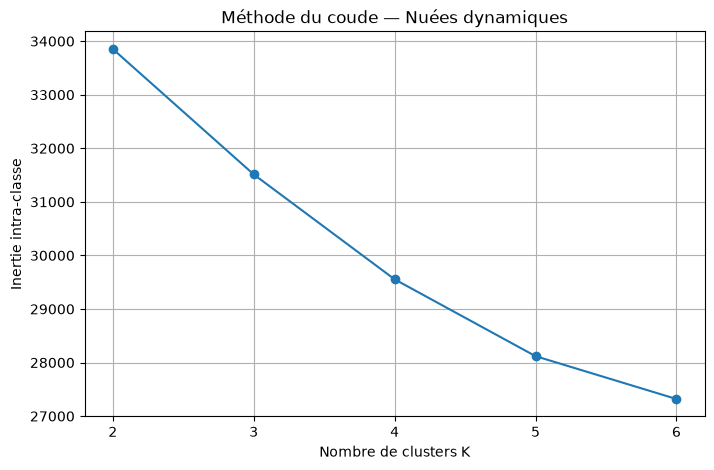

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    resultats_K["K"],
    resultats_K["Inertie"],
    marker="o"
)

plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie intra-classe")
plt.title("Méthode du coude — Nuées dynamiques")

plt.xticks(resultats_K["K"])

plt.grid(True)

plt.show()

In [35]:
def matrice_distances(X):
    """
    Calcule la matrice complète des distances euclidiennes
    sans utiliser sklearn.
    """
    
    n = len(X)
    
    D = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1, n):
            
            d = distance_euclidienne(
                X[i],
                X[j]
            )
            
            D[i, j] = d
            D[j, i] = d
    
    return D

In [36]:
def matrice_distances_rapide(X):
    """
    Matrice des distances euclidiennes.
    Même principe mathématique, calcul vectorisé.
    """
    
    differences = X[:, np.newaxis, :] - X[np.newaxis, :, :]
    
    D = np.sqrt(
        np.sum(differences ** 2, axis=2)
    )
    
    return D

In [37]:
D = matrice_distances_rapide(X_standardise)

print("Dimensions de la matrice :", D.shape)
print("Distance client 1-client 1 :", D[0, 0])
print("Distance client 1-client 2 :", D[0, 1])

Dimensions de la matrice : (2667, 2667)
Distance client 1-client 1 : 0.0
Distance client 1-client 2 : 3.4484724036096384


In [38]:
def distance_moyenne_interne(D, labels, i):
    
    cluster_i = labels[i]
    
    indices = np.where(
        labels == cluster_i
    )[0]
    
    # Retirer l'individu lui-même
    indices = indices[indices != i]
    
    if len(indices) == 0:
        return 0.0
    
    return np.mean(
        D[i, indices]
    )

In [39]:
a0 = distance_moyenne_interne(
    D,
    labels,
    0
)

print("a(0) =", a0)

a(0) = 3.8942078933976108


In [40]:
def distance_moyenne_externe(D, labels, i, K):
    
    cluster_i = labels[i]
    
    distances_clusters = []
    
    for k in range(K):
        
        if k == cluster_i:
            continue
        
        indices = np.where(
            labels == k
        )[0]
        
        if len(indices) > 0:
            
            distance = np.mean(
                D[i, indices]
            )
            
            distances_clusters.append(
                distance
            )
    
    return min(distances_clusters)

In [41]:
b0 = distance_moyenne_externe(
    D,
    labels,
    0,
    K=3
)

print("b(0) =", b0)

b(0) = 4.60144743138901


In [42]:
def silhouette_individuelle(D, labels, i, K):
    
    a = distance_moyenne_interne(
        D,
        labels,
        i
    )
    
    b = distance_moyenne_externe(
        D,
        labels,
        i,
        K
    )
    
    if max(a, b) == 0:
        return 0.0
    
    s = (b - a) / max(a, b)
    
    return s

In [43]:
s0 = silhouette_individuelle(
    D,
    labels,
    0,
    K=3
)

print("Silhouette du client 0 :", s0)

Silhouette du client 0 : 0.15369936276288382


In [44]:
def silhouette_moyenne(D, labels, K):
    
    silhouettes = []
    
    for i in range(len(labels)):
        
        s = silhouette_individuelle(
            D,
            labels,
            i,
            K
        )
        
        silhouettes.append(s)
    
    return np.mean(silhouettes)

In [45]:
silhouette = silhouette_moyenne(
    D,
    labels,
    K=3
)

print("Silhouette moyenne :", silhouette)

Silhouette moyenne : 0.08173360097517249


In [49]:
def calculer_silhouette_pour_K(
    D,
    X,
    K_values,
    max_iter=100,
    tol=1e-4,
    random_state=42
):
    
    resultats = []
    
    for K in K_values:
        
        print("\n" + "=" * 50)
        print(f"K = {K}")
        print("=" * 50)
        
        # Nuées dynamiques
        resultat = nuees_dynamiques(
            X,
            K=K,
            max_iter=max_iter,
            tol=tol,
            random_state=random_state
        )
        
        labels_K = resultat["labels"]
        
        # Silhouette
        silhouette_K = silhouette_moyenne(
            D,
            labels_K,
            K
        )
        
        print(
            f"Silhouette moyenne = {silhouette_K:.6f}"
        )
        
        resultats.append({
            "K": K,
            "Inertie": resultat["inertie"],
            "Silhouette": silhouette_K,
            "Iterations": resultat["iterations"]
        })
    
    return pd.DataFrame(resultats)

In [50]:
K_values = [2, 3, 4, 5, 6]

resultats_complets = calculer_silhouette_pour_K(
    D,
    X_standardise,
    K_values
)

display(resultats_complets)


K = 2
Itération   1 | Inertie = 34489.7111 | Variation = 3.809826
Itération   2 | Inertie = 34148.6829 | Variation = 0.330957
Itération   3 | Inertie = 34035.1935 | Variation = 0.188572
Itération   4 | Inertie = 33993.8947 | Variation = 0.109657
Itération   5 | Inertie = 33974.6751 | Variation = 0.078297
Itération   6 | Inertie = 33968.0117 | Variation = 0.045580
Itération   7 | Inertie = 33965.4168 | Variation = 0.028132
Itération   8 | Inertie = 33963.6626 | Variation = 0.026208
Itération   9 | Inertie = 33962.4691 | Variation = 0.020375
Itération  10 | Inertie = 33961.7676 | Variation = 0.017573
Itération  11 | Inertie = 33961.1771 | Variation = 0.016570
Itération  12 | Inertie = 33960.8550 | Variation = 0.011738
Itération  13 | Inertie = 33960.7352 | Variation = 0.006890
Itération  14 | Inertie = 33960.3960 | Variation = 0.013753
Itération  15 | Inertie = 33959.8145 | Variation = 0.016180
Itération  16 | Inertie = 33958.6801 | Variation = 0.021956
Itération  17 | Inertie = 33957.5

,K,Inertie,Silhouette,Iterations
0,2,33853.975846,0.090280,100
1,3,31513.012046,0.081734,52
2,4,29554.187544,0.082376,43
3,5,28119.765053,0.083200,13
4,6,27319.953204,0.075440,21


In [51]:
def tester_stabilite(
    X,
    D,
    K,
    seeds,
    max_iter=100,
    tol=1e-4
):
    
    resultats = []
    
    for seed in seeds:
        
        resultat = nuees_dynamiques(
            X,
            K=K,
            max_iter=max_iter,
            tol=tol,
            random_state=seed
        )
        
        labels = resultat["labels"]
        
        silhouette = silhouette_moyenne(
            D,
            labels,
            K
        )
        
        resultats.append({
            "K": K,
            "Seed": seed,
            "Inertie": resultat["inertie"],
            "Silhouette": silhouette,
            "Iterations": resultat["iterations"]
        })
    
    return pd.DataFrame(resultats)

In [52]:
seeds = [10, 20, 30, 40, 50]

stabilite = []

for K in [2, 4, 5]:
    
    resultat_K = tester_stabilite(
        X_standardise,
        D,
        K,
        seeds
    )
    
    stabilite.append(resultat_K)

stabilite = pd.concat(
    stabilite,
    ignore_index=True
)

display(stabilite)

Itération   1 | Inertie = 35735.6620 | Variation = 5.989027
Itération   2 | Inertie = 34851.7600 | Variation = 0.684172
Itération   3 | Inertie = 34296.7093 | Variation = 0.442923
Itération   4 | Inertie = 34026.8978 | Variation = 0.295974
Itération   5 | Inertie = 33925.6926 | Variation = 0.165347
Itération   6 | Inertie = 33885.4046 | Variation = 0.108754
Itération   7 | Inertie = 33875.4725 | Variation = 0.050486
Itération   8 | Inertie = 33873.2439 | Variation = 0.023866
Itération   9 | Inertie = 33872.3056 | Variation = 0.018221
Itération  10 | Inertie = 33872.0000 | Variation = 0.012312
Itération  11 | Inertie = 33871.4897 | Variation = 0.015443
Itération  12 | Inertie = 33871.2546 | Variation = 0.010534
Itération  13 | Inertie = 33871.0473 | Variation = 0.010267
Itération  14 | Inertie = 33870.9577 | Variation = 0.006306
Itération  15 | Inertie = 33870.9324 | Variation = 0.003566
Itération  16 | Inertie = 33870.9324 | Variation = 0.000000

Convergence atteinte.
Itération   1 | I

,K,Seed,Inertie,Silhouette,Iterations
0,2,10,33870.932373,0.089338,16
1,2,20,33809.595933,0.091517,23
2,2,30,33849.144701,0.089408,32
3,2,40,33843.247496,0.090682,42
4,2,50,33831.598669,0.091084,70
5,4,10,29606.776471,0.082444,25
6,4,20,29631.023096,0.081955,28
7,4,30,29579.221779,0.081617,100
8,4,40,29747.038198,0.080723,46
9,4,50,29567.821573,0.082080,68


In [53]:
resultat_K2 = nuees_dynamiques(
    X_standardise,
    K=2,
    max_iter=200,
    tol=1e-4,
    random_state=20
)

labels_K2 = resultat_K2["labels"]

print("Inertie :", resultat_K2["inertie"])
print("Itérations :", resultat_K2["iterations"])

print("\nTaille des clusters :")

for k in range(2):
    nombre = np.sum(labels_K2 == k)
    pourcentage = nombre / len(labels_K2) * 100
    
    print(
        f"Cluster {k+1}: "
        f"{nombre} clients "
        f"({pourcentage:.2f}%)"
    )

Itération   1 | Inertie = 34407.5930 | Variation = 4.943875
Itération   2 | Inertie = 34039.6356 | Variation = 0.329526
Itération   3 | Inertie = 33914.7333 | Variation = 0.182383
Itération   4 | Inertie = 33881.6789 | Variation = 0.096156
Itération   5 | Inertie = 33871.3315 | Variation = 0.059363
Itération   6 | Inertie = 33863.7152 | Variation = 0.055091
Itération   7 | Inertie = 33859.1777 | Variation = 0.038124
Itération   8 | Inertie = 33853.2796 | Variation = 0.053076
Itération   9 | Inertie = 33846.7927 | Variation = 0.049893
Itération  10 | Inertie = 33837.9777 | Variation = 0.057553
Itération  11 | Inertie = 33832.6803 | Variation = 0.041598
Itération  12 | Inertie = 33828.7057 | Variation = 0.038389
Itération  13 | Inertie = 33826.7144 | Variation = 0.028673
Itération  14 | Inertie = 33823.0683 | Variation = 0.040748
Itération  15 | Inertie = 33818.1544 | Variation = 0.044657
Itération  16 | Inertie = 33815.6254 | Variation = 0.026326
Itération  17 | Inertie = 33813.4260 | V

In [55]:
# ============================================
# ANALYSE DU CHURN PAR CLUSTER
# ============================================

analyse_K2 = pd.DataFrame({
    "Cluster": labels_K2,
    "Churn": y.values
})

# Conversion de Churn en variable binaire
# False. -> 0
# True.  -> 1

analyse_K2["Churn_binaire"] = (
    analyse_K2["Churn"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(".", "", regex=False)
    .map({
        "false": 0,
        "true": 1
    })
)

# Vérification
print("Valeurs de Churn après conversion :")
print(analyse_K2["Churn_binaire"].value_counts(dropna=False))

# Vérifier qu'aucune valeur n'a été perdue
print(
    "\nNombre de valeurs manquantes :",
    analyse_K2["Churn_binaire"].isna().sum()
)

# Calcul du taux de churn
churn_par_cluster = (
    analyse_K2
    .groupby("Cluster")["Churn_binaire"]
    .mean()
    * 100
)

print("\n====================================")
print("TAUX DE CHURN PAR CLUSTER")
print("====================================")

for cluster, taux in churn_par_cluster.items():
    print(
        f"Cluster {cluster + 1} : {taux:.2f}%"
    )

Valeurs de Churn après conversion :
Churn_binaire
0    2289
1     378
Name: count, dtype: int64

Nombre de valeurs manquantes : 0

TAUX DE CHURN PAR CLUSTER
Cluster 1 : 10.94%
Cluster 2 : 17.68%


In [56]:
# ============================================
# PROFIL DES CLUSTERS
# ============================================

profil_K2 = X.copy()

profil_K2["Cluster"] = labels_K2

profil = (
    profil_K2
    .groupby("Cluster")
    .mean()
)

display(profil)

,Account.Length,Day.Mins,Day.Calls,Day.Charge,Eve.Mins,Eve.Calls,Eve.Charge,Night.Mins,Night.Calls,Night.Charge,Intl.Mins,Intl.Calls,Intl.Charge,CustServ.Calls
Cluster,,,,,,,,,,,,,,
0,101.274298,147.994384,99.971922,25.159662,212.289921,99.75450,18.044852,223.854716,100.685385,10.073521,10.523686,4.480202,2.841886,1.550036
1,101.215962,214.269875,100.444444,36.426330,189.706025,100.63615,16.125219,175.249922,99.583725,7.886338,9.955790,4.546948,2.688685,1.587637


In [57]:
# ============================================
# ECART ENTRE LES CLUSTERS
# ============================================

ecarts = profil.loc[1] - profil.loc[0]

ecarts_relatifs = (
    (profil.loc[1] - profil.loc[0])
    / profil.loc[0]
    * 100
)

comparaison = pd.DataFrame({
    "Cluster_1": profil.loc[0],
    "Cluster_2": profil.loc[1],
    "Ecart": ecarts,
    "Ecart_relatif_%": ecarts_relatifs
})

display(comparaison)

,Cluster_1,Cluster_2,Ecart,Ecart_relatif_%
Account.Length,101.274298,101.215962,-0.058336,-0.057602
Day.Mins,147.994384,214.269875,66.275490,44.782436
Day.Calls,99.971922,100.444444,0.472522,0.472655
Day.Charge,25.159662,36.426330,11.266669,44.780684
Eve.Mins,212.289921,189.706025,-22.583896,-10.638233
Eve.Calls,99.754500,100.636150,0.881651,0.883820
Eve.Charge,18.044852,16.125219,-1.919633,-10.638121
Night.Mins,223.854716,175.249922,-48.604794,-21.712651
Night.Calls,100.685385,99.583725,-1.101661,-1.094161
Night.Charge,10.073521,7.886338,-2.187182,-21.712196


In [58]:
# ============================================
# MATRICE DE CORRELATION
# ============================================

correlations = X.corr()

display(correlations.round(3))

,Account.Length,Day.Mins,Day.Calls,Day.Charge,Eve.Mins,Eve.Calls,Eve.Charge,Night.Mins,Night.Calls,Night.Charge,Intl.Mins,Intl.Calls,Intl.Charge,CustServ.Calls
Account.Length,1.000,0.003,0.046,0.003,-0.013,0.016,-0.013,0.007,0.003,0.007,0.003,0.029,0.003,-0.014
Day.Mins,0.003,1.000,0.010,1.000,-0.008,0.028,-0.008,-0.018,0.013,-0.018,-0.020,0.014,-0.020,-0.014
Day.Calls,0.046,0.010,1.000,0.010,-0.017,0.020,-0.017,0.010,-0.027,0.010,0.009,-0.000,0.009,-0.009
Day.Charge,0.003,1.000,0.010,1.000,-0.008,0.028,-0.008,-0.018,0.013,-0.018,-0.020,0.014,-0.020,-0.014
Eve.Mins,-0.013,-0.008,-0.017,-0.008,1.000,-0.022,1.000,0.004,0.000,0.004,-0.015,-0.012,-0.015,-0.012
Eve.Calls,0.016,0.028,0.020,0.028,-0.022,1.000,-0.022,0.017,0.014,0.017,0.001,0.011,0.001,-0.016
Eve.Charge,-0.013,-0.008,-0.017,-0.008,1.000,-0.022,1.000,0.004,0.000,0.004,-0.015,-0.012,-0.015,-0.012
Night.Mins,0.007,-0.018,0.010,-0.018,0.004,0.017,0.004,1.000,0.017,1.000,-0.004,-0.004,-0.004,-0.013
Night.Calls,0.003,0.013,-0.027,0.013,0.000,0.014,0.000,0.017,1.000,0.017,-0.005,0.001,-0.005,-0.009
Night.Charge,0.007,-0.018,0.010,-0.018,0.004,0.017,0.004,1.000,0.017,1.000,-0.004,-0.004,-0.004,-0.012


In [59]:
# ============================================
# COUPLES DE VARIABLES FORTEMENT CORRELES
# ============================================

corr_abs = correlations.abs()

for i in range(len(corr_abs.columns)):
    for j in range(i + 1, len(corr_abs.columns)):
        
        valeur = corr_abs.iloc[i, j]
        
        if valeur >= 0.80:
            print(
                f"{corr_abs.columns[i]} <-> "
                f"{corr_abs.columns[j]} : "
                f"{valeur:.3f}"
            )

Day.Mins <-> Day.Charge : 1.000
Eve.Mins <-> Eve.Charge : 1.000
Night.Mins <-> Night.Charge : 1.000
Intl.Mins <-> Intl.Charge : 1.000


In [60]:
variables_clustering = [
    "Account.Length",
    "Day.Mins",
    "Day.Calls",
    "Eve.Mins",
    "Eve.Calls",
    "Night.Mins",
    "Night.Calls",
    "Intl.Mins",
    "Intl.Calls",
    "CustServ.Calls"
]

X_reduit = df[variables_clustering].copy()

In [61]:
# Variables retenues pour le clustering
variables_clustering = [
    "Account.Length",
    "Day.Mins",
    "Day.Calls",
    "Eve.Mins",
    "Eve.Calls",
    "Night.Mins",
    "Night.Calls",
    "Intl.Mins",
    "Intl.Calls",
    "CustServ.Calls"
]

# Nouvelle matrice
X_reduit = df[variables_clustering].copy()

# Conversion en matrice numérique
X_reduit_array = X_reduit.to_numpy(dtype=float)

# Standardisation
moyennes_reduites = np.mean(X_reduit_array, axis=0)
ecarts_types_reduits = np.std(X_reduit_array, axis=0)

X_standardise_reduit = (
    X_reduit_array - moyennes_reduites
) / ecarts_types_reduits

print("Nombre d'observations :", X_standardise_reduit.shape[0])
print("Nombre de variables :", X_standardise_reduit.shape[1])
print("\nVariables utilisées :")
for variable in variables_clustering:
    print("-", variable)

Nombre d'observations : 2667
Nombre de variables : 10

Variables utilisées :
- Account.Length
- Day.Mins
- Day.Calls
- Eve.Mins
- Eve.Calls
- Night.Mins
- Night.Calls
- Intl.Mins
- Intl.Calls
- CustServ.Calls


In [62]:
resultats_k_reduit = []

for K in range(2, 7):

    print("\n" + "="*60)
    print(f"NUÉES DYNAMIQUES — K = {K}")
    print("="*60)

    resultat = nuees_dynamiques(
        X_standardise_reduit,
        K=K,
        max_iter=200,
        tol=1e-4,
        random_state=42
    )

    resultats_k_reduit.append({
        "K": K,
        "Inertie": resultat["inertie"],
        "Iterations": resultat["iterations"],
        "Labels": resultat["labels"],
        "Prototypes": resultat["prototypes"]
    })


NUÉES DYNAMIQUES — K = 2
Itération   1 | Inertie = 24971.0896 | Variation = 3.179847
Itération   2 | Inertie = 24877.5429 | Variation = 0.171687
Itération   3 | Inertie = 24833.5642 | Variation = 0.120652
Itération   4 | Inertie = 24806.8288 | Variation = 0.090569
Itération   5 | Inertie = 24792.1719 | Variation = 0.067489
Itération   6 | Inertie = 24782.3764 | Variation = 0.055729
Itération   7 | Inertie = 24776.5013 | Variation = 0.047309
Itération   8 | Inertie = 24773.0228 | Variation = 0.036592
Itération   9 | Inertie = 24771.5963 | Variation = 0.017142
Itération  10 | Inertie = 24770.4076 | Variation = 0.024527
Itération  11 | Inertie = 24769.6544 | Variation = 0.015138
Itération  12 | Inertie = 24769.0175 | Variation = 0.016520
Itération  13 | Inertie = 24768.3886 | Variation = 0.013457
Itération  14 | Inertie = 24767.8129 | Variation = 0.015464
Itération  15 | Inertie = 24767.5336 | Variation = 0.011319
Itération  16 | Inertie = 24767.2806 | Variation = 0.009503
Itération  17 

In [63]:
tableau_inertie_reduit = pd.DataFrame([
    {
        "K": r["K"],
        "Inertie": r["Inertie"],
        "Iterations": r["Iterations"]
    }
    for r in resultats_k_reduit
])

display(tableau_inertie_reduit)

,K,Inertie,Iterations
0,2,24766.735916,22
1,3,23389.647031,96
2,4,22327.624638,50
3,5,21372.378981,71
4,6,20611.064803,50


In [64]:
id="h4m8pc"
tableau_inertie_reduit["Baisse_absolue"] = (
    tableau_inertie_reduit["Inertie"].shift(1)
    - tableau_inertie_reduit["Inertie"]
)

tableau_inertie_reduit["Baisse_relative_%"] = (
    tableau_inertie_reduit["Baisse_absolue"]
    / tableau_inertie_reduit["Inertie"].shift(1)
) * 100

display(tableau_inertie_reduit)

,K,Inertie,Iterations,Baisse_absolue,Baisse_relative_%
0,2,24766.735916,22,NaN,NaN
1,3,23389.647031,96,1377.088885,5.560236
2,4,22327.624638,50,1062.022393,4.540566
3,5,21372.378981,71,955.245657,4.278313
4,6,20611.064803,50,761.314178,3.562141


In [65]:
id="w5n2kx"
D_reduit = matrice_distances_rapide(X_standardise_reduit)

print("Matrice des distances :", D_reduit.shape)
print("Distance D[0,1] :", D_reduit[0, 1])

Matrice des distances : (2667, 2667)
Distance D[0,1] : 2.550559844552705


In [66]:
id="q9t7va"
resultats_silhouette_reduit = []

for r in resultats_k_reduit:

    K = r["K"]
    labels = r["Labels"]

    silhouette = silhouette_moyenne(
        D_reduit,
        labels,
        K
    )

    resultats_silhouette_reduit.append({
        "K": K,
        "Silhouette": silhouette
    })

tableau_silhouette_reduit = pd.DataFrame(
    resultats_silhouette_reduit
)

display(tableau_silhouette_reduit)

,K,Silhouette
0,2,0.071061
1,3,0.070071
2,4,0.070107
3,5,0.067985
4,6,0.067960


In [67]:
def nuees_dynamiques_silencieuses(
    X, K, max_iter=200, tol=1e-4, random_state=42
):
    prototypes = initialiser_prototypes(
        X, K, random_state
    )

    for iteration in range(max_iter):

        labels = affecter_individus(
            X, prototypes
        )

        nouveaux_prototypes = recalculer_prototypes(
            X,
            labels,
            K,
            prototypes
        )

        variation = changement_prototypes(
            prototypes,
            nouveaux_prototypes
        )

        prototypes = nouveaux_prototypes

        if variation < tol:
            break

    inertie = calculer_inertie(
        X,
        labels,
        prototypes
    )

    return {
        "labels": labels,
        "prototypes": prototypes,
        "inertie": inertie,
        "iterations": iteration + 1
    }

In [68]:
graines = [10, 20, 30, 40, 50]
K_a_tester = [2, 3, 4]

resultats_stabilite = []

for K in K_a_tester:

    for seed in graines:

        resultat = nuees_dynamiques_silencieuses(
            X_standardise_reduit,
            K=K,
            max_iter=200,
            tol=1e-4,
            random_state=seed
        )

        silhouette = silhouette_moyenne(
            D_reduit,
            resultat["labels"],
            K
        )

        resultats_stabilite.append({
            "K": K,
            "Seed": seed,
            "Inertie": resultat["inertie"],
            "Silhouette": silhouette,
            "Iterations": resultat["iterations"]
        })

tableau_stabilite = pd.DataFrame(
    resultats_stabilite
)

display(tableau_stabilite)

,K,Seed,Inertie,Silhouette,Iterations
0,2,10,24760.640443,0.071250,66
1,2,20,24798.965358,0.070225,58
2,2,30,24762.970956,0.071317,67
3,2,40,24759.887408,0.071301,92
4,2,50,24884.997194,0.067491,40
5,3,10,23389.319487,0.069975,111
6,3,20,23537.748864,0.063223,34
7,3,30,23502.933697,0.063506,85
8,3,40,23544.674131,0.063494,38
9,3,50,23517.793412,0.066660,50


In [69]:
synthese_stabilite = (
    tableau_stabilite
    .groupby("K")
    .agg(
        Inertie_moyenne=("Inertie", "mean"),
        Inertie_ecart_type=("Inertie", "std"),
        Silhouette_moyenne=("Silhouette", "mean"),
        Silhouette_min=("Silhouette", "min"),
        Silhouette_max=("Silhouette", "max"),
        Iterations_moyennes=("Iterations", "mean"),
        Iterations_max=("Iterations", "max")
    )
    .reset_index()
)

display(synthese_stabilite.round(6))

,K,Inertie_moyenne,Inertie_ecart_type,Silhouette_moyenne,Silhouette_min,Silhouette_max,Iterations_moyennes,Iterations_max
0,2,24793.492272,53.719609,0.070317,0.067491,0.071317,64.6,92
1,3,23498.493918,63.215507,0.065372,0.063223,0.069975,63.6,111
2,4,22368.376236,73.347823,0.067172,0.064662,0.071960,59.2,84


In [70]:
def rand_index(labels_a, labels_b):
    n = len(labels_a)

    concordants = 0
    total = 0

    for i in range(n):
        for j in range(i + 1, n):

            meme_a = labels_a[i] == labels_a[j]
            meme_b = labels_b[i] == labels_b[j]

            if meme_a == meme_b:
                concordants += 1

            total += 1

    return concordants / total

In [71]:
def ari_depuis_scratch(labels_a, labels_b):

    labels_a = np.asarray(labels_a)
    labels_b = np.asarray(labels_b)

    n = len(labels_a)

    # Création des classes
    classes_a = np.unique(labels_a)
    classes_b = np.unique(labels_b)

    # Matrice de contingence
    table = np.zeros(
        (len(classes_a), len(classes_b)),
        dtype=int
    )

    for i, classe_a in enumerate(classes_a):
        for j, classe_b in enumerate(classes_b):
            table[i, j] = np.sum(
                (labels_a == classe_a) &
                (labels_b == classe_b)
            )

    # Fonction combinaison n parmi 2
    def combinaison2(x):
        return x * (x - 1) / 2

    # Somme des paires dans les cellules
    somme_cellules = np.sum(
        combinaison2(table)
    )

    # Sommes marginales
    sommes_lignes = np.sum(table, axis=1)
    sommes_colonnes = np.sum(table, axis=0)

    somme_lignes = np.sum(
        combinaison2(sommes_lignes)
    )

    somme_colonnes = np.sum(
        combinaison2(sommes_colonnes)
    )

    total_paires = combinaison2(n)

    esperance = (
        somme_lignes * somme_colonnes
    ) / total_paires

    maximum = (
        somme_lignes + somme_colonnes
    ) / 2

    denominateur = maximum - esperance

    if denominateur == 0:
        return 1.0

    ari = (
        somme_cellules - esperance
    ) / denominateur

    return ari

In [72]:
partitions = {}

for K in [2, 3, 4]:

    partitions[K] = {}

    for seed in [10, 20, 30, 40, 50]:

        resultat = nuees_dynamiques_silencieuses(
            X_standardise_reduit,
            K=K,
            max_iter=200,
            tol=1e-4,
            random_state=seed
        )

        partitions[K][seed] = resultat["labels"]

In [73]:
resultats_ari = []

for K in [2, 3, 4]:

    reference = partitions[K][10]

    for seed in [20, 30, 40, 50]:

        ari = ari_depuis_scratch(
            reference,
            partitions[K][seed]
        )

        resultats_ari.append({
            "K": K,
            "Reference": 10,
            "Seed": seed,
            "ARI": ari
        })

tableau_ari = pd.DataFrame(resultats_ari)

display(
    tableau_ari.round(6)
)

,K,Reference,Seed,ARI
0,2,10,20,0.333606
1,2,10,30,0.765127
2,2,10,40,0.869523
3,2,10,50,0.000020
4,3,10,20,0.236065
5,3,10,30,0.187809
6,3,10,40,0.248437
7,3,10,50,0.215682
8,4,10,20,0.343328
9,4,10,30,0.478990


In [74]:
for K in [2, 3, 4]:

    print("\n" + "="*50)
    print(f"K = {K}")
    print("="*50)

    for seed in [10, 20, 30, 40, 50]:

        labels = partitions[K][seed]

        tailles = np.bincount(labels)

        proportions = tailles / len(labels) * 100

        print(
            f"Seed {seed} : "
            f"tailles = {tailles.tolist()} | "
            f"proportions = {np.round(proportions, 2).tolist()}"
        )


K = 2
Seed 10 : tailles = [1336, 1331] | proportions = [50.09, 49.91]
Seed 20 : tailles = [1349, 1318] | proportions = [50.58, 49.42]
Seed 30 : tailles = [1361, 1306] | proportions = [51.03, 48.97]
Seed 40 : tailles = [1340, 1327] | proportions = [50.24, 49.76]
Seed 50 : tailles = [1318, 1349] | proportions = [49.42, 50.58]

K = 3
Seed 10 : tailles = [605, 1040, 1022] | proportions = [22.68, 39.0, 38.32]
Seed 20 : tailles = [888, 906, 873] | proportions = [33.3, 33.97, 32.73]
Seed 30 : tailles = [958, 873, 836] | proportions = [35.92, 32.73, 31.35]
Seed 40 : tailles = [890, 760, 1017] | proportions = [33.37, 28.5, 38.13]
Seed 50 : tailles = [682, 904, 1081] | proportions = [25.57, 33.9, 40.53]

K = 4
Seed 10 : tailles = [761, 705, 762, 439] | proportions = [28.53, 26.43, 28.57, 16.46]
Seed 20 : tailles = [455, 874, 464, 874] | proportions = [17.06, 32.77, 17.4, 32.77]
Seed 30 : tailles = [867, 666, 722, 412] | proportions = [32.51, 24.97, 27.07, 15.45]
Seed 40 : tailles = [761, 657, 8

In [75]:
labels_20 = partitions[2][20]
labels_50 = partitions[2][50]

ari_normal = ari_depuis_scratch(
    labels_20,
    labels_50
)

ari_inverse = ari_depuis_scratch(
    labels_20,
    1 - labels_50
)

print("ARI normal  :", ari_normal)
print("ARI inversé :", ari_inverse)

ARI normal  : 0.03809467640561709
ARI inversé : 0.03809467640561709


In [76]:
def matrice_contingence(labels_a, labels_b):

    classes_a = np.unique(labels_a)
    classes_b = np.unique(labels_b)

    table = np.zeros(
        (len(classes_a), len(classes_b)),
        dtype=int
    )

    for i, classe_a in enumerate(classes_a):
        for j, classe_b in enumerate(classes_b):
            table[i, j] = np.sum(
                (labels_a == classe_a) &
                (labels_b == classe_b)
            )

    return pd.DataFrame(
        table,
        index=[f"A_{c}" for c in classes_a],
        columns=[f"B_{c}" for c in classes_b]
    )

table_contingence = matrice_contingence(
    labels_20,
    labels_50
)

display(table_contingence)

,B_0,B_1
A_0,536,813
A_1,782,536


In [77]:
meilleures_solutions = []

for K in [2, 3, 4]:

    sous_table = tableau_stabilite[
        tableau_stabilite["K"] == K
    ]

    ligne = sous_table.loc[
        sous_table["Inertie"].idxmin()
    ]

    meilleures_solutions.append(ligne)

meilleures_solutions = pd.DataFrame(
    meilleures_solutions
).reset_index(drop=True)

display(
    meilleures_solutions.round(6)
)

,K,Seed,Inertie,Silhouette,Iterations
0,2.0,40.0,24759.887408,0.071301,92.0
1,3.0,10.0,23389.319487,0.069975,111.0
2,4.0,20.0,22259.126246,0.071960,33.0


In [78]:
for _, ligne in meilleures_solutions.iterrows():

    K = int(ligne["K"])
    seed = int(ligne["Seed"])

    print(
        f"K = {K} | "
        f"Seed retenue = {seed} | "
        f"Inertie = {ligne['Inertie']:.4f} | "
        f"Silhouette = {ligne['Silhouette']:.6f}"
    )

K = 2 | Seed retenue = 40 | Inertie = 24759.8874 | Silhouette = 0.071301
K = 3 | Seed retenue = 10 | Inertie = 23389.3195 | Silhouette = 0.069975
K = 4 | Seed retenue = 20 | Inertie = 22259.1262 | Silhouette = 0.071960


In [79]:
solutions_candidates = {
    2: partitions[2][40],
    3: partitions[3][10],
    4: partitions[4][20]
}

In [80]:
profils = {}

for K, labels in solutions_candidates.items():

    donnees_profil = X_reduit.copy()
    donnees_profil["Cluster"] = labels

    profil = donnees_profil.groupby("Cluster").mean()

    profils[K] = profil

    print("\n" + "="*70)
    print(f"PROFIL DES CLUSTERS — K = {K}")
    print("="*70)

    display(profil.round(3))


PROFIL DES CLUSTERS — K = 2


,Account.Length,Day.Mins,Day.Calls,Eve.Mins,Eve.Calls,Night.Mins,Night.Calls,Intl.Mins,Intl.Calls,CustServ.Calls
Cluster,,,,,,,,,,
0,80.022,170.556,92.604,211.880,96.096,194.582,101.506,9.991,3.919,1.935
1,122.678,189.040,107.867,190.954,104.298,206.604,98.796,10.515,5.112,1.197



PROFIL DES CLUSTERS — K = 3


,Account.Length,Day.Mins,Day.Calls,Eve.Mins,Eve.Calls,Night.Mins,Night.Calls,Intl.Mins,Intl.Calls,CustServ.Calls
Cluster,,,,,,,,,,
0,101.255,180.789,99.430,199.681,97.684,194.203,97.183,9.797,4.081,3.415
1,75.590,169.172,93.139,216.737,97.312,197.706,100.119,10.512,3.962,1.017
2,127.349,189.907,107.837,186.988,104.568,207.237,101.957,10.255,5.328,1.035



PROFIL DES CLUSTERS — K = 4


,Account.Length,Day.Mins,Day.Calls,Eve.Mins,Eve.Calls,Night.Mins,Night.Calls,Intl.Mins,Intl.Calls,CustServ.Calls
Cluster,,,,,,,,,,
0,109.774,185.234,98.101,195.411,99.941,214.982,101.200,10.170,8.389,1.281
1,120.579,196.857,110.967,194.272,103.495,188.935,96.667,10.149,3.703,0.997
2,99.998,183.952,100.963,200.575,98.858,197.361,97.397,10.200,3.938,3.735
3,78.137,157.566,90.116,212.291,97.682,206.387,104.571,10.424,3.609,1.138


In [81]:
# Conversion du churn en variable binaire
y_binaire = y.map({
    "False.": 0,
    "True.": 1
})

resultats_churn = []

for K, labels in solutions_candidates.items():

    temp = pd.DataFrame({
        "Cluster": labels,
        "Churn": y_binaire.values
    })

    resume = (
        temp.groupby("Cluster")["Churn"]
        .agg(
            Effectif="count",
            Churns="sum",
            Taux_Churn="mean"
        )
        .reset_index()
    )

    resume["Taux_Churn_%"] = (
        resume["Taux_Churn"] * 100
    )

    resume["K"] = K

    resultats_churn.append(resume)

tableau_churn = pd.concat(
    resultats_churn,
    ignore_index=True
)

tableau_churn = tableau_churn[
    [
        "K",
        "Cluster",
        "Effectif",
        "Churns",
        "Taux_Churn_%"
    ]
]

display(
    tableau_churn.round(3)
)

,K,Cluster,Effectif,Churns,Taux_Churn_%
0,2,0,1340,205,15.299
1,2,1,1327,173,13.037
2,3,0,605,144,23.802
3,3,1,1040,112,10.769
4,3,2,1022,122,11.937
5,4,0,455,51,11.209
6,4,1,874,117,13.387
7,4,2,464,135,29.095
8,4,3,874,75,8.581


In [82]:
from scipy.stats import chi2

def test_chi2_churn(labels, churn):

    # Tableau de contingence
    clusters = np.unique(labels)
    categories_churn = np.array([0, 1])

    table = np.zeros(
        (len(clusters), 2),
        dtype=int
    )

    for i, cluster in enumerate(clusters):
        for j, categorie in enumerate(categories_churn):
            table[i, j] = np.sum(
                (labels == cluster) &
                (churn == categorie)
            )

    # Totaux
    totaux_lignes = table.sum(axis=1)
    totaux_colonnes = table.sum(axis=0)
    total = table.sum()

    # Effectifs théoriques
    effectifs_theoriques = (
        np.outer(totaux_lignes, totaux_colonnes)
        / total
    )

    # Statistique du chi-deux
    chi2_stat = np.sum(
        (table - effectifs_theoriques) ** 2
        / effectifs_theoriques
    )

    # Degrés de liberté
    ddl = (table.shape[0] - 1) * (table.shape[1] - 1)

    # p-value
    p_value = chi2.sf(
        chi2_stat,
        ddl
    )

    return {
        "table": table,
        "effectifs_theoriques": effectifs_theoriques,
        "chi2": chi2_stat,
        "ddl": ddl,
        "p_value": p_value
    }

In [83]:
resultats_chi2 = []

for K, labels in solutions_candidates.items():

    resultat = test_chi2_churn(
        labels,
        y_binaire.values
    )

    resultats_chi2.append({
        "K": K,
        "Chi2": resultat["chi2"],
        "ddl": resultat["ddl"],
        "p_value": resultat["p_value"]
    })

tableau_chi2 = pd.DataFrame(
    resultats_chi2
)

display(
    tableau_chi2.round(6)
)

,K,Chi2,ddl,p_value
0,2,2.803405,1,0.094064
1,3,60.214245,2,0.000000
2,4,111.128118,3,0.000000


In [84]:
K_final = 4
seed_final = 20

modele_final = nuees_dynamiques_silencieuses(
    X_standardise_reduit,
    K=K_final,
    max_iter=200,
    tol=1e-4,
    random_state=seed_final
)

labels_finaux = modele_final["labels"]
prototypes_finaux = modele_final["prototypes"]

print("K final :", K_final)
print("Seed :", seed_final)
print("Inertie finale :", modele_final["inertie"])
print("Nombre d'itérations :", modele_final["iterations"])
print("Silhouette :", silhouette_moyenne(
    D_reduit,
    labels_finaux,
    K_final
))

K final : 4
Seed : 20
Inertie finale : 22259.126245882017
Nombre d'itérations : 33
Silhouette : 0.0719597523526711


In [85]:
tailles_finales = np.bincount(labels_finaux)

proportions_finales = (
    tailles_finales / len(labels_finaux)
) * 100

tableau_final = pd.DataFrame({
    "Cluster": np.arange(K_final),
    "Effectif": tailles_finales,
    "Proportion_%": proportions_finales
})

display(tableau_final.round(3))

,Cluster,Effectif,Proportion_%
0,0,455,17.060
1,1,874,32.771
2,2,464,17.398
3,3,874,32.771


In [86]:
# Données originales + cluster final
df_profil_final = X_reduit.copy()
df_profil_final["Cluster"] = labels_finaux

# Moyennes par cluster
moyennes_clusters = (
    df_profil_final
    .groupby("Cluster")[variables_clustering]
    .mean()
)

# Moyenne globale
moyenne_globale = X_reduit[variables_clustering].mean()

print("MOYENNES PAR CLUSTER")
display(moyennes_clusters.round(3))

print("\nMOYENNE GLOBALE")
display(moyenne_globale.round(3))

MOYENNES PAR CLUSTER


,Account.Length,Day.Mins,Day.Calls,Eve.Mins,Eve.Calls,Night.Mins,Night.Calls,Intl.Mins,Intl.Calls,CustServ.Calls
Cluster,,,,,,,,,,
0,109.774,185.234,98.101,195.411,99.941,214.982,101.200,10.170,8.389,1.281
1,120.579,196.857,110.967,194.272,103.495,188.935,96.667,10.149,3.703,0.997
2,99.998,183.952,100.963,200.575,98.858,197.361,97.397,10.200,3.938,3.735
3,78.137,157.566,90.116,212.291,97.682,206.387,104.571,10.424,3.609,1.138



MOYENNE GLOBALE


Account.Length    101.246
Day.Mins          179.753
Day.Calls         100.198
Eve.Mins          201.468
Eve.Calls         100.177
Night.Mins        200.564
Night.Calls       100.157
Intl.Mins          10.252
Intl.Calls          4.512
CustServ.Calls      1.568
dtype: float64

In [87]:
ecarts_relatifs = (
    (moyennes_clusters - moyenne_globale)
    / moyenne_globale
) * 100

print("ÉCART RELATIF À LA MOYENNE GLOBALE (%)")

display(
    ecarts_relatifs.round(2)
)

ÉCART RELATIF À LA MOYENNE GLOBALE (%)


,Account.Length,Day.Mins,Day.Calls,Eve.Mins,Eve.Calls,Night.Mins,Night.Calls,Intl.Mins,Intl.Calls,CustServ.Calls
Cluster,,,,,,,,,,
0,8.42,3.05,-2.09,-3.01,-0.24,7.19,1.04,-0.80,85.92,-18.29
1,19.09,9.52,10.75,-3.57,3.31,-5.80,-3.48,-1.01,-17.94,-36.45
2,-1.23,2.34,0.76,-0.44,-1.32,-1.60,-2.76,-0.50,-12.74,138.19
3,-22.82,-12.34,-10.06,5.37,-2.49,2.90,4.41,1.69,-20.02,-27.40


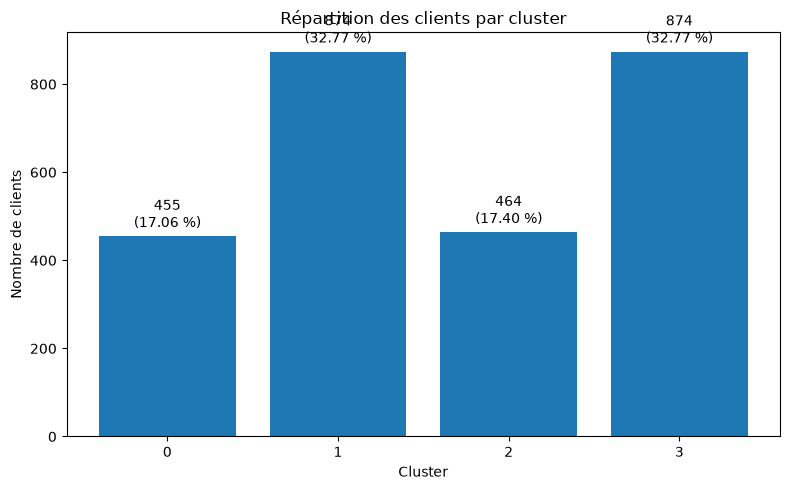

In [90]:
# ============================================================
# VISUALISATION FINALE DES NUÉES DYNAMIQUES
# K = 4
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. EFFECTIFS DES CLUSTERS
# ------------------------------------------------------------

# ============================================================
# GRAPHIQUE 1 — EFFECTIFS DES CLUSTERS
# ============================================================

effectifs_clusters = (
    pd.Series(labels_finaux)
    .value_counts()
    .sort_index()
)

pourcentages_clusters = (
    effectifs_clusters / len(labels_finaux) * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    effectifs_clusters.index.astype(str),
    effectifs_clusters.values
)

plt.xlabel("Cluster")
plt.ylabel("Nombre de clients")
plt.title("Répartition des clients par cluster")

for bar, n, p in zip(
    bars,
    effectifs_clusters.values,
    pourcentages_clusters.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{n}\n({p:.2f} %)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

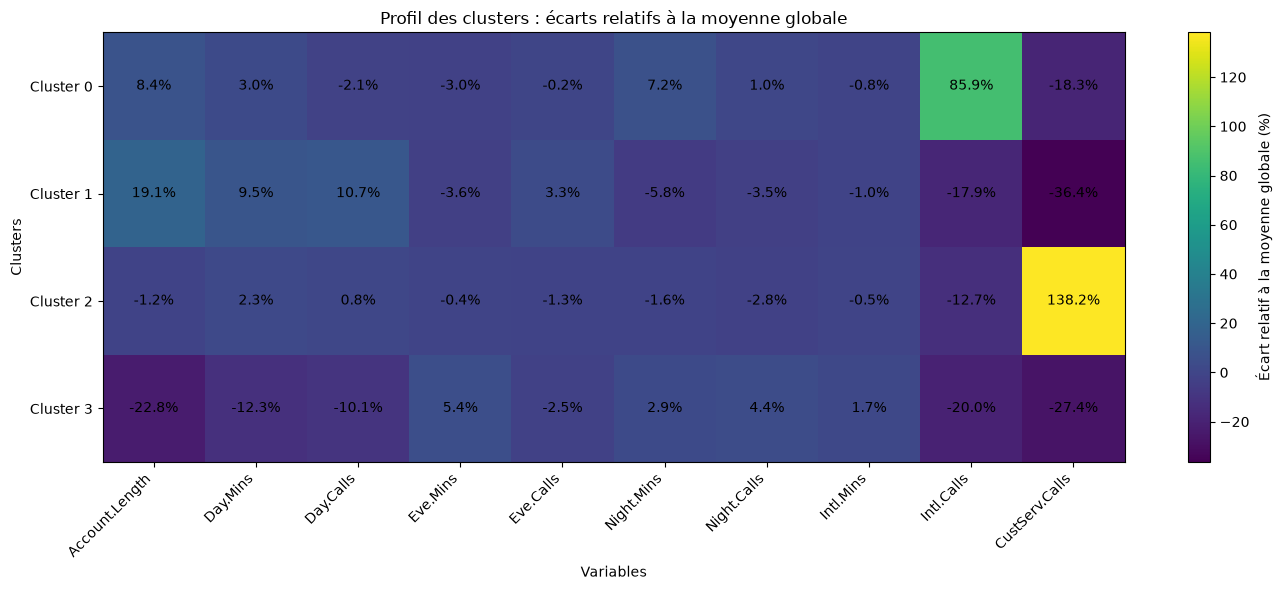

In [91]:
# ============================================================
# GRAPHIQUE 2 — HEATMAP DES PROFILS
# ============================================================

plt.figure(figsize=(14, 6))

plt.imshow(
    ecarts_relatifs.values,
    aspect="auto"
)

plt.colorbar(
    label="Écart relatif à la moyenne globale (%)"
)

plt.xticks(
    range(len(variables_clustering)),
    variables_clustering,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(4),
    ["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"]
)

plt.title(
    "Profil des clusters : écarts relatifs à la moyenne globale"
)

for i in range(ecarts_relatifs.shape[0]):
    for j in range(ecarts_relatifs.shape[1]):

        valeur = ecarts_relatifs.iloc[i, j]

        plt.text(
            j,
            i,
            f"{valeur:.1f}%",
            ha="center",
            va="center"
        )

plt.xlabel("Variables")
plt.ylabel("Clusters")

plt.tight_layout()
plt.show()

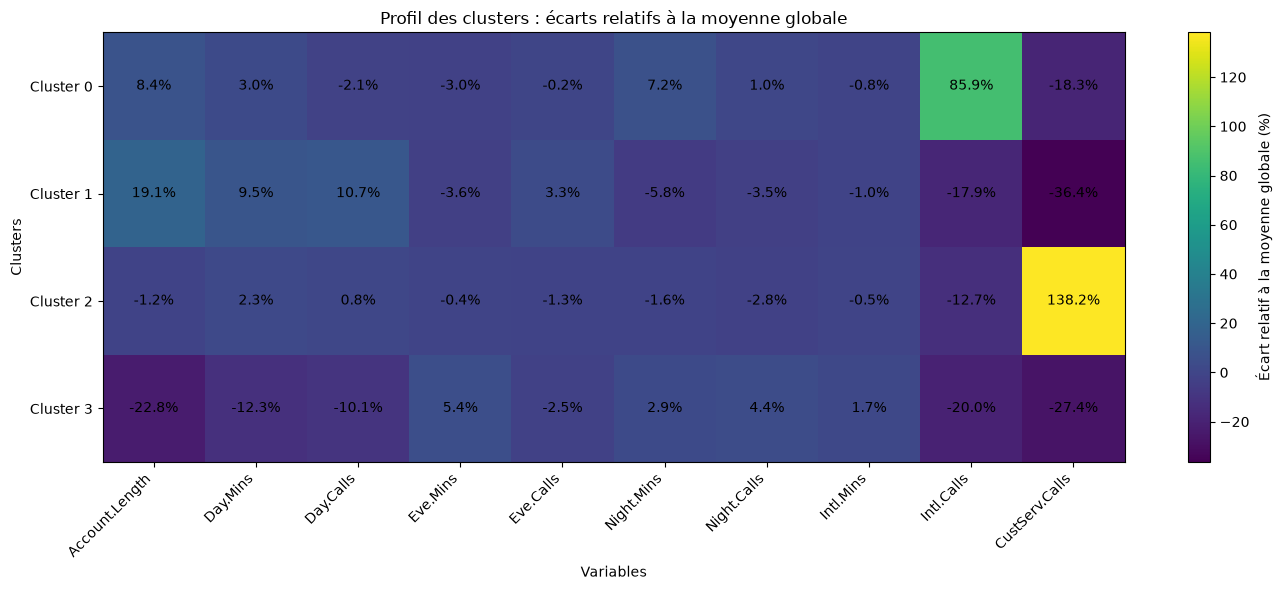

In [92]:
# ============================================================
# GRAPHIQUE 2 — HEATMAP DES PROFILS
# ============================================================

plt.figure(figsize=(14, 6))

plt.imshow(
    ecarts_relatifs.values,
    aspect="auto"
)

plt.colorbar(
    label="Écart relatif à la moyenne globale (%)"
)

plt.xticks(
    range(len(variables_clustering)),
    variables_clustering,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(4),
    ["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"]
)

plt.title(
    "Profil des clusters : écarts relatifs à la moyenne globale"
)

for i in range(ecarts_relatifs.shape[0]):
    for j in range(ecarts_relatifs.shape[1]):

        valeur = ecarts_relatifs.iloc[i, j]

        plt.text(
            j,
            i,
            f"{valeur:.1f}%",
            ha="center",
            va="center"
        )

plt.xlabel("Variables")
plt.ylabel("Clusters")

plt.tight_layout()
plt.show()

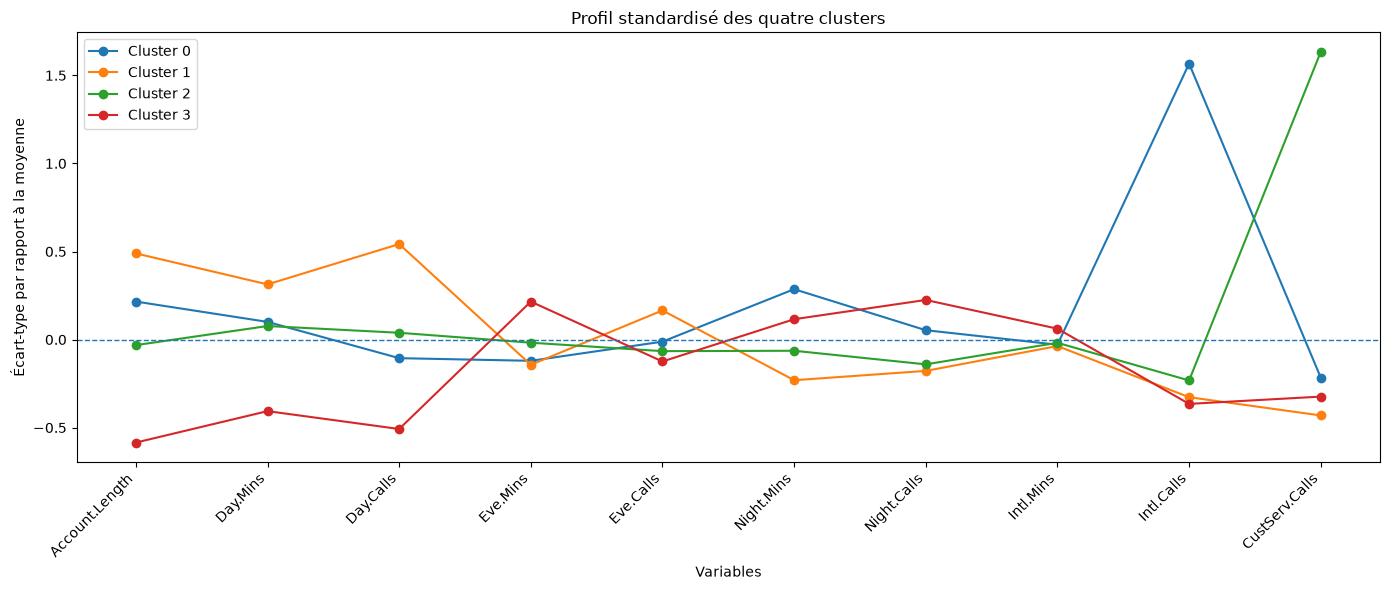

In [93]:
# ============================================================
# GRAPHIQUE 3 — PROFIL STANDARDISÉ DES CLUSTERS
# ============================================================

profil_standardise = (
    moyennes_clusters - moyenne_globale
) / ecarts_types_reduits

plt.figure(figsize=(14, 6))

for cluster in profil_standardise.index:

    plt.plot(
        range(len(variables_clustering)),
        profil_standardise.loc[cluster].values,
        marker="o",
        label=f"Cluster {cluster}"
    )

plt.axhline(
    0,
    linewidth=1,
    linestyle="--"
)

plt.xticks(
    range(len(variables_clustering)),
    variables_clustering,
    rotation=45,
    ha="right"
)

plt.xlabel("Variables")
plt.ylabel("Écart-type par rapport à la moyenne")

plt.title(
    "Profil standardisé des quatre clusters"
)

plt.legend()

plt.tight_layout()
plt.show()

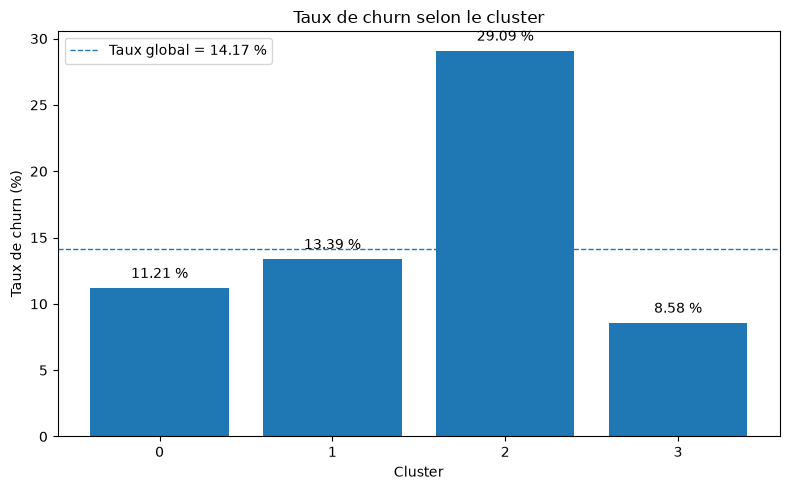

In [94]:
# ============================================================
# GRAPHIQUE 4 — TAUX DE CHURN PAR CLUSTER
# ============================================================

taux_churn_clusters = (
    df_churn_final
    .groupby("Cluster")["Churn_Binaire"]
    .mean()
    * 100
)

taux_churn_global = (
    df_churn_final["Churn_Binaire"].mean()
    * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    taux_churn_clusters.index.astype(str),
    taux_churn_clusters.values
)

# Ligne représentant le taux global
plt.axhline(
    taux_churn_global,
    linewidth=1,
    linestyle="--",
    label=f"Taux global = {taux_churn_global:.2f} %"
)

plt.xlabel("Cluster")
plt.ylabel("Taux de churn (%)")

plt.title(
    "Taux de churn selon le cluster"
)

for bar, taux in zip(
    bars,
    taux_churn_clusters.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{taux:.2f} %",
        ha="center",
        va="bottom"
    )

plt.legend()

plt.tight_layout()
plt.show()